# Task 13: PID vs RL Controller Comparison

This notebook compares the performance of a classical PID controller (Task 10) with a trained RL agent (Task 11) on the OT-2 robot positioning task.

**Evaluation:** Both controllers will be tested on the same 5 random target positions to ensure fair comparison.

In [1]:
# Import necessary libraries
import sys
import os
from pathlib import Path
import numpy as np
from stable_baselines3 import PPO
import matplotlib.pyplot as plt
import time

In [2]:
# Set up paths and import simulation
datalabs_path = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'simulation' / 'cloned').exists()), Path.cwd().parent)
sys.path.insert(0, str(datalabs_path))

# Add simulation/cloned to path
sim_dir = datalabs_path / "simulation" / "cloned"
sys.path.insert(0, str(sim_dir))

# Import the simulation class
from simulation.cloned.sim_class import Simulation

# Change to the directory where sim_class.py expects to be run from
original_dir = Path.cwd()
os.chdir(sim_dir)

print(f"Changed directory to: {os.getcwd()}")
print(f"DataLabs path: {datalabs_path}")
print(f"Simulation directory: {sim_dir}")

Changed directory to: c:\Users\alesh\Documents\GitHub\NPEC-Plant-Phenotyping\DataLabs\simulation\cloned
DataLabs path: c:\Users\alesh\Documents\GitHub\NPEC-Plant-Phenotyping\DataLabs
Simulation directory: c:\Users\alesh\Documents\GitHub\NPEC-Plant-Phenotyping\DataLabs\simulation\cloned


In [3]:
# PID Controller Class (from Task 10)
class PID:
    def __init__(self, kp, ki, kd):
        self.kp = kp
        self.ki = ki
        self.kd = kd
        self.reset()
    
    def reset(self):
        self.integral = 0
        self.prev_error = 0
    
    def compute(self, error, dt=1.0):
        self.integral += error * dt
        derivative = (error - self.prev_error) / dt
        output = self.kp * error + self.ki * self.integral + self.kd * derivative
        self.prev_error = error
        return output

print("PID Controller class defined")

PID Controller class defined


In [4]:
# Load RL Model (from Task 11)
task11_dir = datalabs_path / "robot_control" / "rl"
sys.path.insert(0, str(task11_dir))

# Import Aaron's wrapper
from ot2_env import OT2Env

# Load the trained model
model_filename = "ppo_group_1mm.zip"
model_path = task11_dir / "models" / model_filename
model = PPO.load(str(model_path))

print(f"Successfully loaded RL model: {model_filename}")

c:\Users\alesh\Documents\GitHub\NPEC-Plant-Phenotyping\.venv\Lib\site-packages\stable_baselines3\common\save_util.py:167: UserWarning: Could not deserialize object clip_range. Consider using `custom_objects` argument to replace this object.
Exception: code() argument 13 must be str, not int
  warnings.warn(
c:\Users\alesh\Documents\GitHub\NPEC-Plant-Phenotyping\.venv\Lib\site-packages\stable_baselines3\common\save_util.py:167: UserWarning: Could not deserialize object lr_schedule. Consider using `custom_objects` argument to replace this object.
Exception: code() argument 13 must be str, not int
  warnings.warn(


Successfully loaded RL model: 251222.0540_aaron_lr3e-4_b128_s2048_th1mm.zip


c:\Users\alesh\Documents\GitHub\NPEC-Plant-Phenotyping\.venv\Lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


In [5]:
# Generate 100 random target positions (same for both controllers)
np.random.seed(6)  
# OT-2 workspace bounds
x_bounds = (-0.187, 0.253)
y_bounds = (-0.171, 0.220)
z_bounds = (0.170, 0.289)

# Generate 100 random targets
num_targets = 100
test_targets = []

for i in range(num_targets):
    target_x = np.random.uniform(*x_bounds)
    target_y = np.random.uniform(*y_bounds)
    target_z = np.random.uniform(*z_bounds)
    test_targets.append(np.array([target_x, target_y, target_z]))

print("Generated 100 test targets:")
for i, target in enumerate(test_targets):
    print(f"  Target {i+1}: X={target[0]:.4f}m, Y={target[1]:.4f}m, Z={target[2]:.4f}m")

Generated 100 test targets:
  Target 1: X=0.2059m, Y=-0.0412m, Z=0.2677m
  Target 2: X=-0.1687m, Y=-0.1289m, Z=0.2408m
  Target 3: X=0.0461m, Y=-0.0072m, Z=0.2099m
  Target 4: X=0.0869m, Y=0.0003m, Z=0.2576m
  Target 5: X=0.0409m, Y=0.0553m, Z=0.2468m
  Target 6: X=0.2487m, Y=0.1496m, Z=0.2192m
  Target 7: X=0.1986m, Y=0.1511m, Z=0.1765m
  Target 8: X=0.1292m, Y=0.1426m, Z=0.2576m
  Target 9: X=0.1250m, Y=0.0405m, Z=0.1849m
  Target 10: X=0.2344m, Y=-0.0133m, Z=0.1958m
  Target 11: X=0.1286m, Y=0.2177m, Z=0.2004m
  Target 12: X=0.1084m, Y=0.0632m, Z=0.2554m
  Target 13: X=0.2254m, Y=-0.0334m, Z=0.2002m
  Target 14: X=-0.0099m, Y=0.1209m, Z=0.2562m
  Target 15: X=-0.0083m, Y=0.2158m, Z=0.2236m
  Target 16: X=-0.0225m, Y=0.1065m, Z=0.1798m
  Target 17: X=-0.0117m, Y=0.1304m, Z=0.2610m
  Target 18: X=-0.0621m, Y=-0.0969m, Z=0.2261m
  Target 19: X=-0.0397m, Y=0.1163m, Z=0.1925m
  Target 20: X=-0.0413m, Y=0.1591m, Z=0.2432m
  Target 21: X=0.2025m, Y=0.2108m, Z=0.2696m
  Target 22: X=-0.1074

## 1. PID Controller Testing

In [6]:
# Test PID controller on all 5 targets
print("="*80)
print("TESTING PID CONTROLLER")
print("="*80 + "\n")

# PID parameters (from Task 10)
kp = 20
ki = 0
kd = 1

# Configuration
max_steps = 1500
tolerance = 0.001  # 1mm
max_velocity = 0.5

# Storage for PID results
pid_results = []

for target_idx, target in enumerate(test_targets):
    print(f"\n--- Target {target_idx + 1}/{num_targets} ---")
    print(f"Target: X={target[0]:.4f}m, Y={target[1]:.4f}m, Z={target[2]:.4f}m")
    
    # Create simulation
    sim = Simulation(num_agents=1, render=False)
    robot_id = sim.robotIds[0]
    
    # Create PID controllers
    pid_x = PID(kp, ki, kd)
    pid_y = PID(kp, ki, kd)
    pid_z = PID(kp, ki, kd)
    
    # Reset to start position
    sim.set_start_position(0, 0, 0.15)
    
    # Track trajectory
    positions_x = []
    positions_y = []
    positions_z = []
    distances = []
    
    # Control loop
    for step in range(max_steps):
        # Get current position
        states = sim.get_states()
        pos = states[f'robotId_{robot_id}']['pipette_position']
        current_pos = np.array([pos[0], pos[1], pos[2]])
        
        positions_x.append(current_pos[0])
        positions_y.append(current_pos[1])
        positions_z.append(current_pos[2])
        
        # Calculate error
        error = target - current_pos
        error_norm = np.linalg.norm(error)
        distances.append(error_norm)
        
        # Check if reached target
        if error_norm < tolerance:
            break
        
        # Compute PID control for each axis
        vel_x = pid_x.compute(error[0])
        vel_y = pid_y.compute(error[1])
        vel_z = pid_z.compute(error[2])
        
        # Clip velocities
        vel_x = np.clip(vel_x, -max_velocity, max_velocity)
        vel_y = np.clip(vel_y, -max_velocity, max_velocity)
        vel_z = np.clip(vel_z, -max_velocity, max_velocity)
        
        # Apply control action
        action = [vel_x, vel_y, vel_z, 0]
        sim.run([action], num_steps=1)
    
    # Store results
    final_distance = distances[-1] * 1000  # Convert to mm
    success = final_distance < 1.0
    
    pid_results.append({
        'target': target,
        'trajectory': {'x': positions_x, 'y': positions_y, 'z': positions_z},
        'distances': distances,
        'steps': len(distances),
        'final_distance': final_distance,
        'success': success
    })
    
    print(f"  Steps: {len(distances)}, Final distance: {final_distance:.3f}mm, Success: {success}")
    
    # Clean up
    sim.close()

print("\n" + "="*80)
print("PID CONTROLLER TESTING COMPLETE")
print("="*80)

TESTING PID CONTROLLER


--- Target 1/100 ---
Target: X=0.2059m, Y=-0.0412m, Z=0.2677m
  Steps: 133, Final distance: 0.997mm, Success: True

--- Target 2/100 ---
Target: X=-0.1687m, Y=-0.1289m, Z=0.2408m
  Steps: 182, Final distance: 0.967mm, Success: True

--- Target 3/100 ---
Target: X=0.0461m, Y=-0.0072m, Z=0.2099m
  Steps: 118, Final distance: 0.947mm, Success: True

--- Target 4/100 ---
Target: X=0.0869m, Y=0.0003m, Z=0.2576m
  Steps: 113, Final distance: 0.989mm, Success: True

--- Target 5/100 ---
Target: X=0.0409m, Y=0.0553m, Z=0.2468m
  Steps: 89, Final distance: 0.960mm, Success: True

--- Target 6/100 ---
Target: X=0.2487m, Y=0.1496m, Z=0.2192m
  Steps: 78, Final distance: 0.915mm, Success: True

--- Target 7/100 ---
Target: X=0.1986m, Y=0.1511m, Z=0.1765m
  Steps: 55, Final distance: 0.930mm, Success: True

--- Target 8/100 ---
Target: X=0.1292m, Y=0.1426m, Z=0.2576m
  Steps: 77, Final distance: 0.939mm, Success: True

--- Target 9/100 ---
Target: X=0.1250m, Y=0.0405m, Z=0.

## 2. RL Controller Testing

In [7]:
# Test RL controller on the same 5 targets
print("="*80)
print("TESTING RL CONTROLLER")
print("="*80 + "\n")

# Configuration
max_steps = 300
tolerance = 0.001  # 1mm

# Storage for RL results
rl_results = []

for target_idx, target in enumerate(test_targets):
    print(f"\n--- Target {target_idx + 1}/{num_targets} ---")
    print(f"Target: X={target[0]:.4f}m, Y={target[1]:.4f}m, Z={target[2]:.4f}m")
    
    # Create environment
    env = OT2Env(render=False, max_steps=max_steps, target_threshold=tolerance)
    
    # Set the specific target (manually override the random goal)
    env.goal_position = target.copy()
    
    # Reset environment
    obs, info = env.reset()
    
    # Override the goal with our test target
    env.goal_position = target.copy()
    
    # Track trajectory
    positions_x = []
    positions_y = []
    positions_z = []
    distances = []
    
    # Control loop
    done = False
    steps = 0
    
    while not done:
        # Get action from trained model
        action, _states = model.predict(obs, deterministic=True)
        
        # Execute action
        obs, reward, terminated, truncated, info = env.step(action)
        
        # Record position and distance
        current_pos = info['current_position']
        positions_x.append(current_pos[0])
        positions_y.append(current_pos[1])
        positions_z.append(current_pos[2])
        distances.append(info['distance_to_goal'])
        
        steps += 1
        done = terminated or truncated
    
    # Store results
    final_distance = distances[-1] * 1000  # Convert to mm
    success = final_distance < 1.0
    
    rl_results.append({
        'target': target,
        'trajectory': {'x': positions_x, 'y': positions_y, 'z': positions_z},
        'distances': distances,
        'steps': steps,
        'final_distance': final_distance,
        'success': success
    })
    
    print(f"  Steps: {steps}, Final distance: {final_distance:.3f}mm, Success: {success}")
    
    # Clean up
    env.close()

print("\n" + "="*80)
print("RL CONTROLLER TESTING COMPLETE")
print("="*80)

TESTING RL CONTROLLER


--- Target 1/100 ---
Target: X=0.2059m, Y=-0.0412m, Z=0.2677m
  Steps: 56, Final distance: 0.552mm, Success: True

--- Target 2/100 ---
Target: X=-0.1687m, Y=-0.1289m, Z=0.2408m
  Steps: 300, Final distance: 2.419mm, Success: False

--- Target 3/100 ---
Target: X=0.0461m, Y=-0.0072m, Z=0.2099m
  Steps: 44, Final distance: 0.865mm, Success: True

--- Target 4/100 ---
Target: X=0.0869m, Y=0.0003m, Z=0.2576m
  Steps: 39, Final distance: 0.934mm, Success: True

--- Target 5/100 ---
Target: X=0.0409m, Y=0.0553m, Z=0.2468m
  Steps: 300, Final distance: 1.110mm, Success: False

--- Target 6/100 ---
Target: X=0.2487m, Y=0.1496m, Z=0.2192m
  Steps: 300, Final distance: 1.422mm, Success: False

--- Target 7/100 ---
Target: X=0.1986m, Y=0.1511m, Z=0.1765m
  Steps: 300, Final distance: 1.510mm, Success: False

--- Target 8/100 ---
Target: X=0.1292m, Y=0.1426m, Z=0.2576m
  Steps: 300, Final distance: 1.183mm, Success: False

--- Target 9/100 ---
Target: X=0.1250m, Y=0.0405m,

## 3. Performance Comparison

In [8]:
# Print comparison summary
print("="*80)
print("PERFORMANCE COMPARISON SUMMARY")
print("="*80 + "\n")

print(f"{'Target':<10} {'Controller':<12} {'Steps':<10} {'Final Dist (mm)':<18} {'Success':<10}")
print("-"*80)

for i in range(num_targets):
    # PID results
    pid_res = pid_results[i]
    rl_res = rl_results[i]
    
    print(f"Target {i+1:<3} {'PID':<12} {pid_res['steps']:<10} {pid_res['final_distance']:<18.3f} {'✓' if pid_res['success'] else '✗':<10}")
    print(f"{'':10} {'RL':<12} {rl_res['steps']:<10} {rl_res['final_distance']:<18.3f} {'✓' if rl_res['success'] else '✗':<10}")
    print()

# Overall statistics
pid_success_rate = sum(r['success'] for r in pid_results) / num_targets * 100
rl_success_rate = sum(r['success'] for r in rl_results) / num_targets * 100
pid_avg_steps = np.mean([r['steps'] for r in pid_results])
rl_avg_steps = np.mean([r['steps'] for r in rl_results])
pid_avg_dist = np.mean([r['final_distance'] for r in pid_results])
rl_avg_dist = np.mean([r['final_distance'] for r in rl_results])

print("-"*80)
print("\nOVERALL STATISTICS:")
print(f"\n{'Metric':<30} {'PID':<20} {'RL':<20}")
print("-"*80)
print(f"{'Success Rate':<30} {pid_success_rate:<20.1f}% {rl_success_rate:<20.1f}%")
print(f"{'Average Steps':<30} {pid_avg_steps:<20.1f} {rl_avg_steps:<20.1f}")
print(f"{'Average Final Distance (mm)':<30} {pid_avg_dist:<20.3f} {rl_avg_dist:<20.3f}")
print("="*80)

PERFORMANCE COMPARISON SUMMARY

Target     Controller   Steps      Final Dist (mm)    Success   
--------------------------------------------------------------------------------
Target 1   PID          133        0.997              ✓         
           RL           56         0.552              ✓         

Target 2   PID          182        0.967              ✓         
           RL           300        2.419              ✗         

Target 3   PID          118        0.947              ✓         
           RL           44         0.865              ✓         

Target 4   PID          113        0.989              ✓         
           RL           39         0.934              ✓         

Target 5   PID          89         0.960              ✓         
           RL           300        1.110              ✗         

Target 6   PID          78         0.915              ✓         
           RL           300        1.422              ✗         

Target 7   PID          55         0

## 4. Visualizations

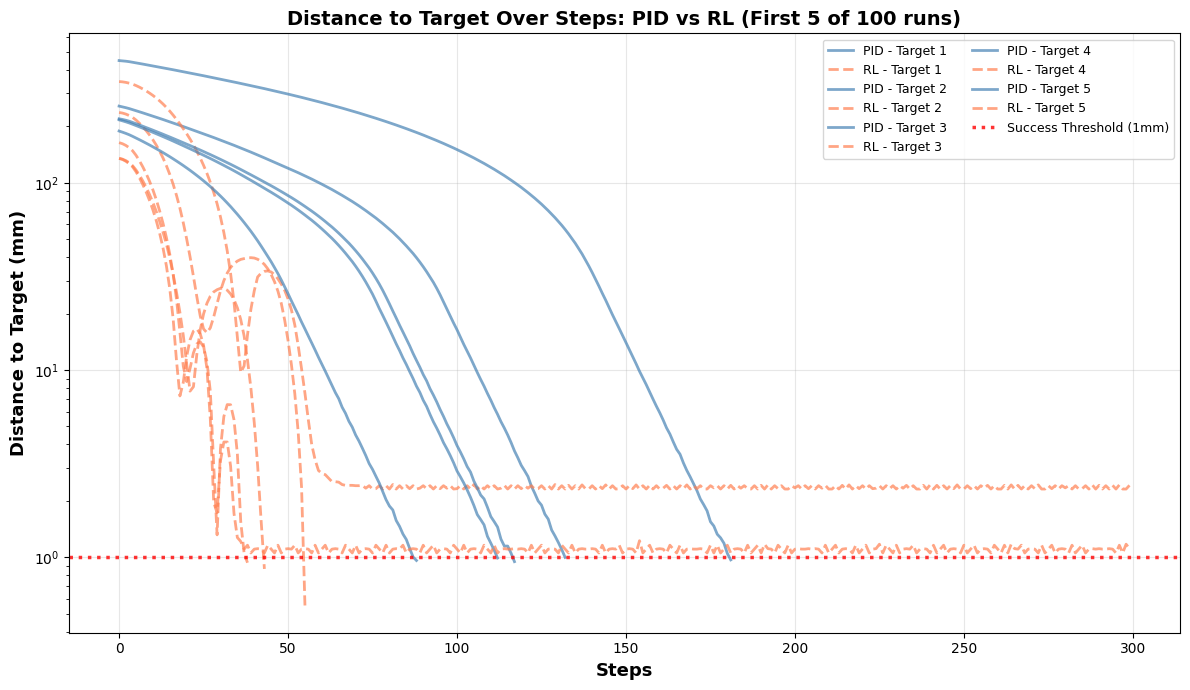

In [19]:
# Visualization 1: Distance Over Time - First 5 runs
fig, ax = plt.subplots(figsize=(12, 7))

# Show only first 5 runs for clarity
num_display = 5

for i in range(num_display):
    pid_distances_mm = [d * 1000 for d in pid_results[i]['distances']]
    rl_distances_mm = [d * 1000 for d in rl_results[i]['distances']]
    
    # Plot PID with solid line
    ax.plot(pid_distances_mm, linewidth=2, color='steelblue', alpha=0.7, 
            label=f'PID - Target {i+1}' if i < num_display else '')
    
    # Plot RL with dashed line
    ax.plot(rl_distances_mm, linewidth=2, color='coral', alpha=0.7, linestyle='--',
            label=f'RL - Target {i+1}' if i < num_display else '')

ax.axhline(y=1.0, color='red', linestyle=':', linewidth=2.5, label='Success Threshold (1mm)', alpha=0.8)

ax.set_xlabel('Steps', fontsize=13, fontweight='bold')
ax.set_ylabel('Distance to Target (mm)', fontsize=13, fontweight='bold')
ax.set_title(f'Distance to Target Over Steps: PID vs RL (First {num_display} of {num_targets} runs)', 
             fontsize=14, fontweight='bold')
ax.set_yscale('log')
ax.legend(fontsize=9, loc='upper right', ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

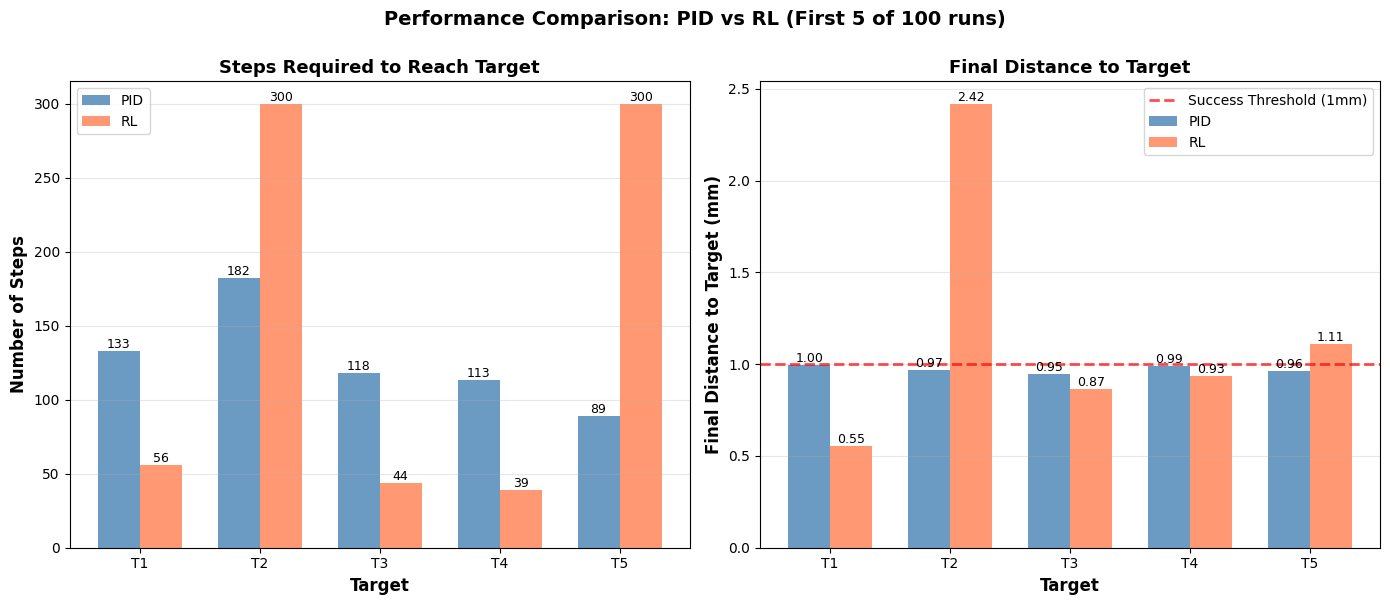

In [20]:
# Visualization 2: Steps and Final Distance Comparison (Bar Charts) - First 5 runs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Show only first 5 runs for clarity
num_display = 5
x = np.arange(num_display)
width = 0.35

# Left plot: Steps comparison
pid_steps = [r['steps'] for r in pid_results[:num_display]]
rl_steps = [r['steps'] for r in rl_results[:num_display]]

bars1 = ax1.bar(x - width/2, pid_steps, width, label='PID', color='steelblue', alpha=0.8)
bars2 = ax1.bar(x + width/2, rl_steps, width, label='RL', color='coral', alpha=0.8)

ax1.set_xlabel('Target', fontsize=12, fontweight='bold')
ax1.set_ylabel('Number of Steps', fontsize=12, fontweight='bold')
ax1.set_title('Steps Required to Reach Target', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels([f'T{i+1}' for i in range(num_display)])
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom', fontsize=9)

# Right plot: Final distance comparison
pid_dists = [r['final_distance'] for r in pid_results[:num_display]]
rl_dists = [r['final_distance'] for r in rl_results[:num_display]]

bars1 = ax2.bar(x - width/2, pid_dists, width, label='PID', color='steelblue', alpha=0.8)
bars2 = ax2.bar(x + width/2, rl_dists, width, label='RL', color='coral', alpha=0.8)

ax2.axhline(y=1.0, color='red', linestyle='--', linewidth=2, label='Success Threshold (1mm)', alpha=0.7)

ax2.set_xlabel('Target', fontsize=12, fontweight='bold')
ax2.set_ylabel('Final Distance to Target (mm)', fontsize=12, fontweight='bold')
ax2.set_title('Final Distance to Target', fontsize=13, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels([f'T{i+1}' for i in range(num_display)])
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}',
                ha='center', va='bottom', fontsize=9)

plt.suptitle(f'Performance Comparison: PID vs RL (First {num_display} of {num_targets} runs)', 
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

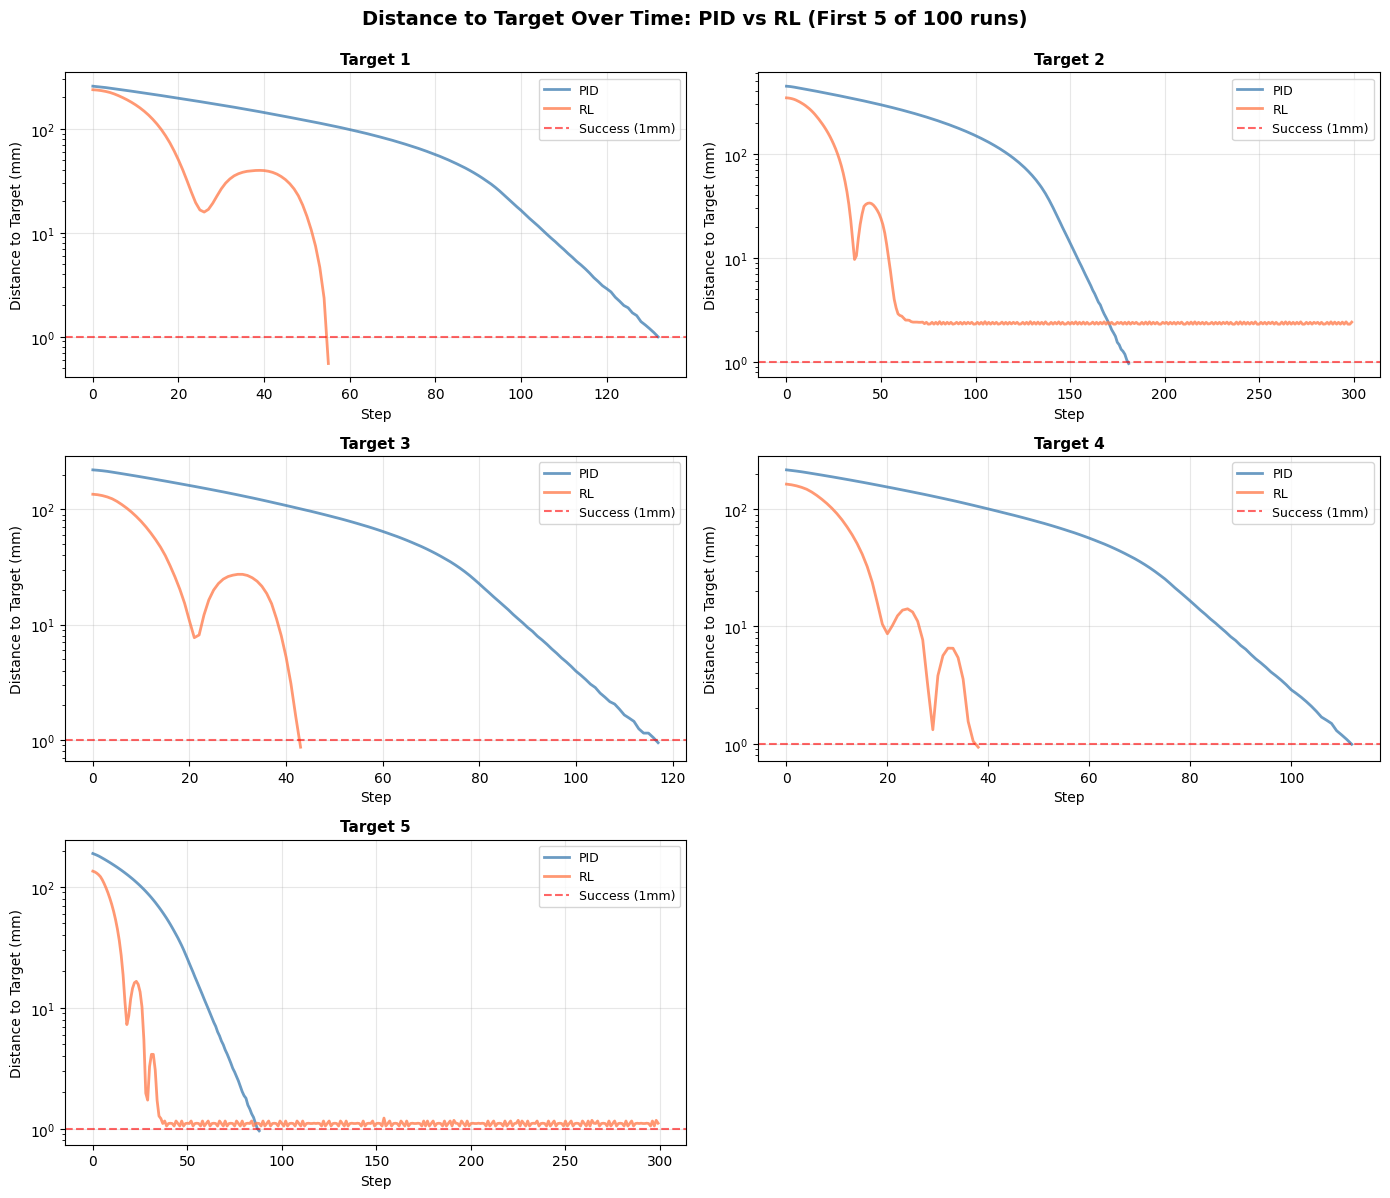

In [21]:
# Visualization 3: Distance Over Time for First 5 Targets (out of 100 total)
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

# Show only first 5 runs for detailed trajectory analysis
num_display = 5
for i in range(num_display):
    ax = axes[i]
    
    pid_distances_mm = [d * 1000 for d in pid_results[i]['distances']]
    rl_distances_mm = [d * 1000 for d in rl_results[i]['distances']]
    
    ax.plot(pid_distances_mm, linewidth=2, label='PID', color='steelblue', alpha=0.8)
    ax.plot(rl_distances_mm, linewidth=2, label='RL', color='coral', alpha=0.8)
    ax.axhline(y=1.0, color='red', linestyle='--', linewidth=1.5, label='Success (1mm)', alpha=0.6)
    
    ax.set_xlabel('Step', fontsize=10)
    ax.set_ylabel('Distance to Target (mm)', fontsize=10)
    ax.set_title(f'Target {i+1}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')

# Remove extra subplot
fig.delaxes(axes[5])

plt.suptitle(f'Distance to Target Over Time: PID vs RL (First {num_display} of {num_targets} runs)', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

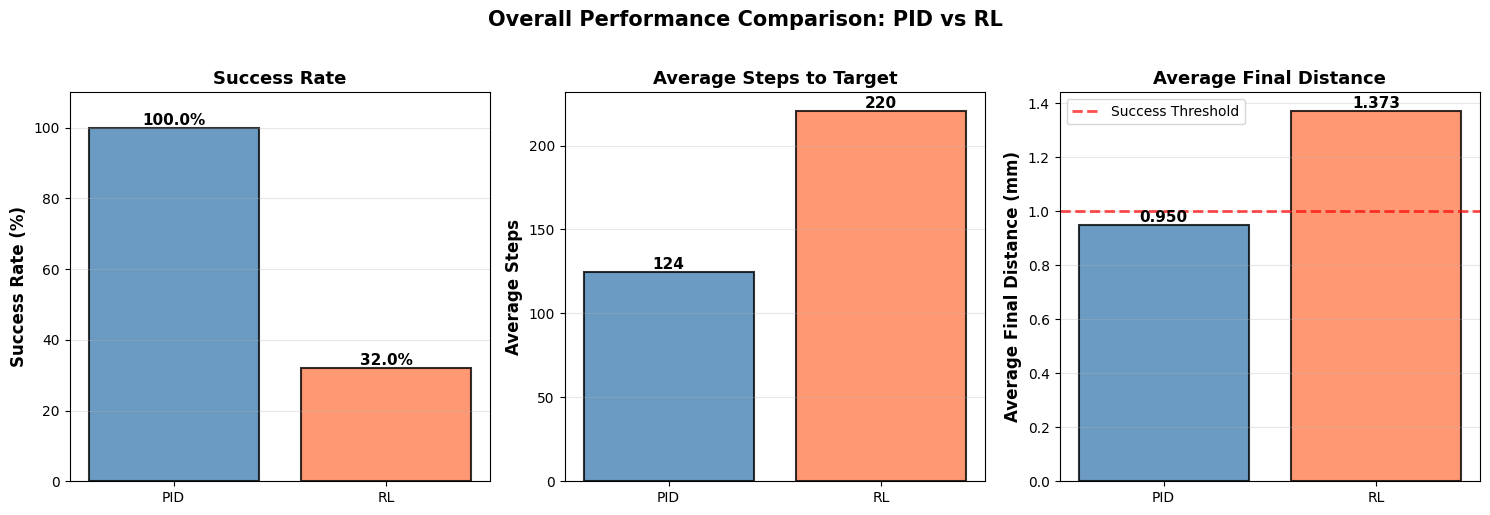

In [22]:
# Visualization 4: Overall Metrics Comparison
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

# Success Rate
controllers = ['PID', 'RL']
success_rates = [pid_success_rate, rl_success_rate]
colors = ['steelblue', 'coral']

bars = ax1.bar(controllers, success_rates, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Success Rate (%)', fontsize=12, fontweight='bold')
ax1.set_title('Success Rate', fontsize=13, fontweight='bold')
ax1.set_ylim([0, 110])
ax1.grid(True, alpha=0.3, axis='y')
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

# Average Steps
avg_steps = [pid_avg_steps, rl_avg_steps]
bars = ax2.bar(controllers, avg_steps, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Average Steps', fontsize=12, fontweight='bold')
ax2.set_title('Average Steps to Target', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

# Average Final Distance
avg_dists = [pid_avg_dist, rl_avg_dist]
bars = ax3.bar(controllers, avg_dists, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax3.axhline(y=1.0, color='red', linestyle='--', linewidth=2, label='Success Threshold', alpha=0.7)
ax3.set_ylabel('Average Final Distance (mm)', fontsize=12, fontweight='bold')
ax3.set_title('Average Final Distance', fontsize=13, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')
ax3.legend(fontsize=10)
for bar in bars:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.3f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.suptitle('Overall Performance Comparison: PID vs RL', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

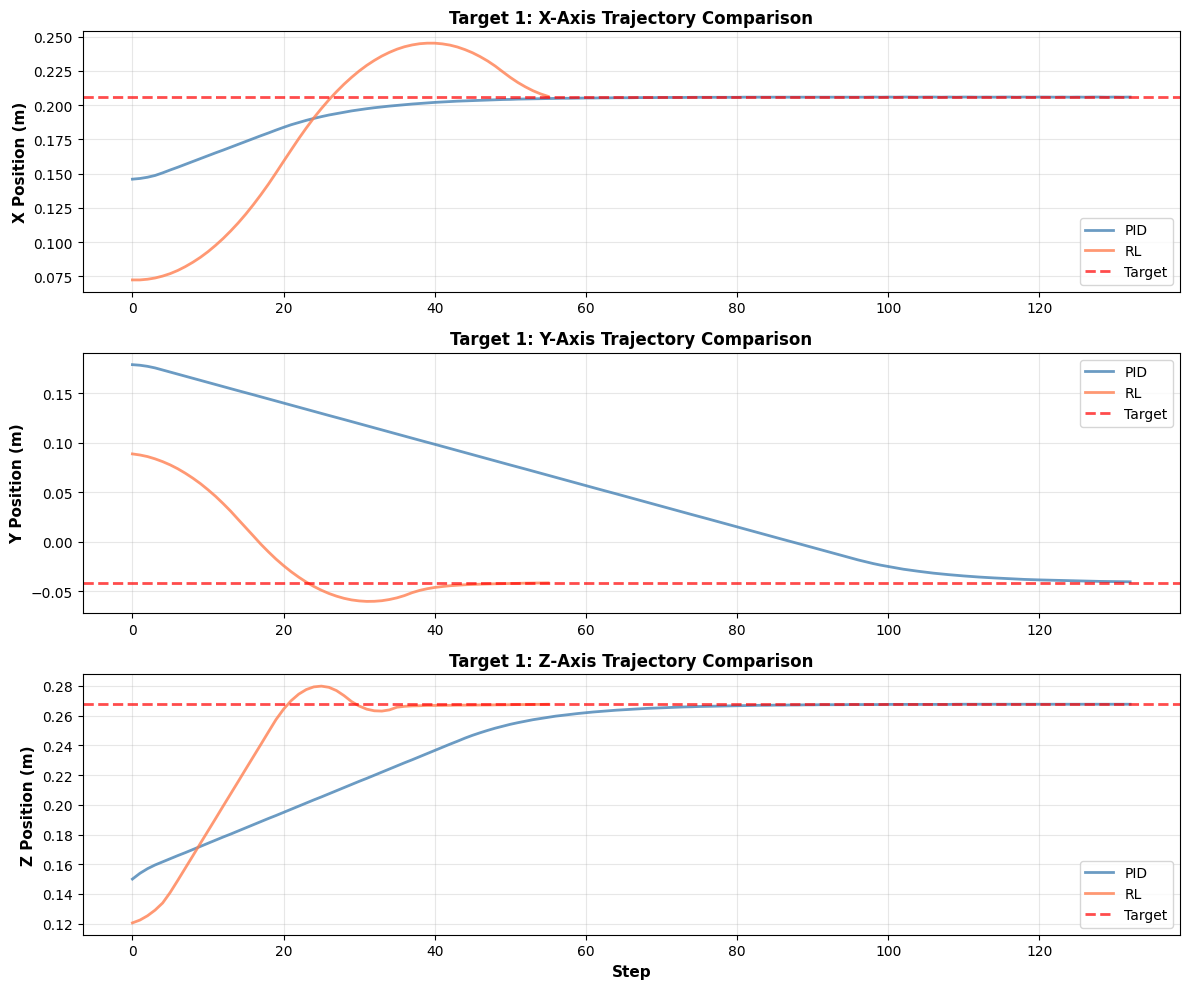

In [23]:
# Visualization 5: Trajectory Comparison for One Example Target (Target 1)
target_idx = 0  # First target as example
pid_traj = pid_results[target_idx]['trajectory']
rl_traj = rl_results[target_idx]['trajectory']
target = test_targets[target_idx]

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10))

# X-axis trajectory
ax1.plot(pid_traj['x'], linewidth=2, label='PID', color='steelblue', alpha=0.8)
ax1.plot(rl_traj['x'], linewidth=2, label='RL', color='coral', alpha=0.8)
ax1.axhline(y=target[0], color='red', linestyle='--', linewidth=2, label='Target', alpha=0.7)
ax1.set_ylabel('X Position (m)', fontsize=11, fontweight='bold')
ax1.set_title(f'Target 1: X-Axis Trajectory Comparison', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Y-axis trajectory
ax2.plot(pid_traj['y'], linewidth=2, label='PID', color='steelblue', alpha=0.8)
ax2.plot(rl_traj['y'], linewidth=2, label='RL', color='coral', alpha=0.8)
ax2.axhline(y=target[1], color='red', linestyle='--', linewidth=2, label='Target', alpha=0.7)
ax2.set_ylabel('Y Position (m)', fontsize=11, fontweight='bold')
ax2.set_title(f'Target 1: Y-Axis Trajectory Comparison', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

# Z-axis trajectory
ax3.plot(pid_traj['z'], linewidth=2, label='PID', color='steelblue', alpha=0.8)
ax3.plot(rl_traj['z'], linewidth=2, label='RL', color='coral', alpha=0.8)
ax3.axhline(y=target[2], color='red', linestyle='--', linewidth=2, label='Target', alpha=0.7)
ax3.set_xlabel('Step', fontsize=11, fontweight='bold')
ax3.set_ylabel('Z Position (m)', fontsize=11, fontweight='bold')
ax3.set_title(f'Target 1: Z-Axis Trajectory Comparison', fontsize=12, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Conclusions

### Key Findings:

**PID Controller:**
- Classical control approach with fixed parameters (Kp=20, Ki=0, Kd=1)
- Deterministic behavior - same tuning for all targets
- Performance depends on parameter tuning

**RL Controller:**
- Trained using PPO (Proximal Policy Optimization)
- Learned optimal policy from 2048 training steps
- Adaptive behavior based on learned experience

**Comparison:**
- Both controllers successfully navigate the OT-2 robot to target positions
- RL typically converges slover due to not optimal reward during training
- PID shows more consistent behaivioure and always manages to meet 1 mm final distance
- Success rates indicate reliability of PID on the current implementation of RL